# 01 — Validación de instancias

Este notebook valida un **conjunto de instancias** del generador de puntos de
recogida de residuos: una por cada **radio** de la lista `RADIOS`
(p. ej. 250, 300, 350, 400 m). Para cada instancia se hace una validación
individual en tres secciones y, al final, una **tabla comparativa**.

- **Sección A — Integridad del grafo**: conectividad, integridad de aristas,
  longitudes y nodos artificiales de la red de calles descargada de OSMnx.
- **Sección B — Demanda y outliers**: distribución de la población estimada `h_i`,
  detección de outliers y calibración a la densidad oficial (INE ≈ 4471 hab/km²).
- **Sección C — Distancias y cobertura**: distancias edificio→candidato, chequeos
  de sanidad y cobertura por tipo de residuo.

Cada sección se encapsula en una función parametrizada por radio
(`validar_grafo`, `validar_demanda`, `validar_distancias_cobertura`) que muestra
sus gráficos y devuelve las métricas clave. Las celdas de ejecución recorren
`RADIOS` llamando a cada función; **si una instancia no existe en disco, se avisa
y se omite** sin romper el bucle. La **tabla comparativa** final reúne todas las
métricas para verificar de un vistazo la coherencia entre instancias: densidad
≈ 4471 hab/km², cobertura total (0 edificios sin cubrir) y edificios / candidatos
/ conexiones crecientes con el radio.

In [2]:
import os
import sys
sys.path.insert(0, "../src/python")  # para importar `instancia`

import numpy as np
import matplotlib.pyplot as plt
import osmnx as ox
import networkx as nx
import geopandas as gpd
import pandas as pd
from IPython.display import display

from instancia import load_instance

# ── Instancias a validar (una por radio) ──────────────────
RADIOS = [1250, 1500]

# ── Constantes compartidas ────────────────────────────────
DATA_DIR = "../data/processed"
DENSIDAD_INE = 4471.0                        # hab/km² (INE 2025, núcleo de La Laguna)
TIPO_NOMBRES = {0: "Orgánico", 1: "Resto", 2: "Papel/Carton", 3: "Vidrio"}

## Sección A — Integridad del grafo y la descarga

Antes de validar edificios o distancias, comprobamos que la **red de calles**
descargada de OSMnx es sólida. Verificamos:

- **Tamaño y conectividad**: nº de nodos y aristas, y si el grafo es conexo
  (un grafo fragmentado daría distancias `inf` entre zonas).
- **Integridad de aristas**: que todas tengan atributo `length` (en metros) y
  que ninguna sea de longitud cero o nula.
- **Distribución de longitudes**: un histograma de las longitudes de arista.
  Aristas anormalmente largas (>500m en un casco urbano) suelen indicar un
  error de descarga o una vía no peatonal mal filtrada.
- **Candidatos artificiales insertados**: los nodos negativos que `ensure_coverage`
  añadió sobre las aristas, para confirmar que la cirugía del grafo funcionó.
- **Nodos aislados**: componentes de tamaño 1 que darían distancias `inf`; se
  comprueba su grado y, si la instancia está disponible, si son candidatos.

Si esta sección pasa, la base topológica es fiable.

In [3]:
def validar_grafo(radius):
    """Sección A — Valida la integridad topológica de la red de calles.

    Para el grafo ``graph_{radius}m.graphml`` comprueba:
      A1. Conectividad: nº de componentes conexas (un grafo fragmentado daría
          distancias infinitas entre zonas).
      A2. Integridad de aristas: que todas tengan ``length`` > 0 (en metros).
      A3. Candidatos artificiales: nodos de id negativo insertados por
          ``ensure_coverage`` sobre las aristas.
      A4. Visualización: mapa de la red + histograma de longitudes de arista.
      A5. Aristas anormalmente largas (>500 m), señal de descarga sospechosa.
      Diag. Nodos aislados (componentes de tamaño 1): su grado y, si la instancia
          está disponible, si son candidatos del problema.

    Si el grafo no existe en disco, avisa y devuelve ``None`` (el bucle continúa).
    Devuelve un dict con las métricas de grafo de la instancia.
    """
    graph_path = f"{DATA_DIR}/graph_{radius}m.graphml"
    if not os.path.exists(graph_path):
        print(f"  ⚠️  No existe {graph_path} — se omite la validación del grafo {radius}m.")
        return None

    # ── Cargar el grafo lat/lon (el que se guarda para mapas) ──
    G = ox.load_graphml(graph_path)
    print(f"CRS: {G.graph.get('crs')}")
    print(f"Nodos: {G.number_of_nodes()}  Aristas: {G.number_of_edges()}")

    # ── A1. Conectividad ──────────────────────────────────────
    # Convertimos a no dirigido para evaluar conectividad real
    # (en un MultiDiGraph dirigido, "fuertemente conexo" es muy estricto;
    #  lo relevante para caminar es que sea conexo sin direcciones).
    G_undirected = ox.convert.to_undirected(G)
    n_components = nx.number_connected_components(G_undirected)
    is_connected = n_components == 1
    print(f"\n── Conectividad ──")
    print(f"Componentes conexas: {n_components}")
    print(f"¿Grafo conexo?: {'✓ SÍ' if is_connected else '✗ NO — hay zonas aisladas'}")
    if not is_connected:
        sizes = [len(c) for c in nx.connected_components(G_undirected)]
        print(f"Tamaño de componentes: {sorted(sizes, reverse=True)}")

    # ── A2. Integridad de aristas (length) ────────────────────
    lengths = []
    edges_sin_length = 0
    for u, v, k, data in G.edges(keys=True, data=True):
        L = data.get("length")
        if L is None or L <= 0:
            edges_sin_length += 1
        else:
            lengths.append(L)
    lengths = np.array(lengths)
    print(f"\n── Integridad de aristas ──")
    print(f"Aristas sin length o length≤0: {edges_sin_length}")
    print(f"Longitud arista: min={lengths.min():.1f}m  "
          f"media={lengths.mean():.1f}m  max={lengths.max():.1f}m")

    # ── A3. Candidatos artificiales (nodos negativos) ─────────
    # Algunos graphml guardan los ids como string; comparamos por el prefijo "-".
    art_nodes_str = [n for n in G.nodes if str(n).startswith("-")]
    print(f"\n── Candidatos artificiales en el grafo ──")
    print(f"Nodos artificiales (insertados sobre arista): {len(art_nodes_str)}")

    # ── A4. Visualización: red + histograma de longitudes ─────
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

    # Mapa de la red
    edges_gdf = ox.graph_to_gdfs(G, nodes=False)
    edges_gdf.plot(ax=ax1, linewidth=0.7, edgecolor="#34495e")
    # Marcar nodos artificiales en rojo si los hay
    if art_nodes_str:
        art_x = [G.nodes[n]["x"] for n in art_nodes_str]
        art_y = [G.nodes[n]["y"] for n in art_nodes_str]
        ax1.scatter(art_x, art_y, s=60, c="red", marker="^",
                    edgecolors="darkred", zorder=5,
                    label=f"Artificiales ({len(art_nodes_str)})")
        ax1.legend(fontsize=10)
    ax1.set_title(f"Red de calles {radius}m — {G.number_of_nodes()} nodos, "
                  f"{G.number_of_edges()} aristas", fontsize=12, fontweight="bold")
    ax1.set_xlabel("Longitud"); ax1.set_ylabel("Latitud")

    # Histograma de longitudes
    ax2.hist(lengths, bins=40, color="#5dade2", edgecolor="white")
    ax2.axvline(lengths.mean(), color="red", linestyle="--",
                label=f"Media: {lengths.mean():.0f}m")
    ax2.axvline(500, color="orange", linestyle=":",
                label="Umbral sospecha (500m)")
    ax2.set_title(f"Distribución de longitudes de arista — {radius}m",
                  fontsize=12, fontweight="bold")
    ax2.set_xlabel("Longitud (m)"); ax2.set_ylabel("Nº de aristas")
    ax2.legend(fontsize=10)

    plt.tight_layout()
    plt.show()

    # ── A5. Aristas sospechosamente largas ────────────────────
    largas = [(u, v, data.get("length", 0)) for u, v, k, data in G.edges(keys=True, data=True)
              if data.get("length", 0) > 500]
    print(f"\n── Aristas > 500m (revisar) ──")
    print(f"Cantidad: {len(largas)}")
    for u, v, L in sorted(largas, key=lambda x: -x[2])[:5]:
        print(f"  {u}→{v}: {L:.0f}m")

    # ── Diagnóstico: nodos aislados (componentes de tamaño 1) ──
    componentes = list(nx.connected_components(G_undirected))
    nodos_aislados = [list(c)[0] for c in componentes if len(c) == 1]
    print(f"\n── Nodos aislados ──")
    print(f"Nodos aislados (componentes de tamaño 1): {len(nodos_aislados)}")
    if nodos_aislados:
        print(f"IDs: {nodos_aislados}")
        # ¿Están en los candidatos de la instancia? (solo si la instancia existe)
        inst_path = f"{DATA_DIR}/instancia_laguna_{radius}m.json"
        if os.path.exists(inst_path):
            inst = load_instance(inst_path)
            cand_osm_ids = {str(inst.J[j].osm_id) for j in inst.J}
            aislados_cand = [n for n in nodos_aislados if str(n) in cand_osm_ids]
            print(f"De esos aislados, ¿cuántos son candidatos?: {len(aislados_cand)}  "
                  f"IDs: {aislados_cand}")
        else:
            print(f"  (instancia {radius}m no disponible: se omite el cruce con candidatos)")
        print(f"Grado de cada nodo aislado (en grafo dirigido original):")
        for n in nodos_aislados:
            print(f"  nodo {n}: grado {G.degree(n)}, "
                  f"street_count={G.nodes[n].get('street_count', '?')}")

    return {
        "radius": radius,
        "n_nodos": G.number_of_nodes(),
        "n_aristas": G.number_of_edges(),
        "conexo": is_connected,
        "n_componentes": n_components,
        "n_nodos_artificiales": len(art_nodes_str),
        "n_aristas_largas": len(largas),
    }


════════════════════════════════════════════════════════════
═══ Sección A · Instancia 1250m ═══
════════════════════════════════════════════════════════════
CRS: epsg:4326
Nodos: 1477  Aristas: 4126

── Conectividad ──
Componentes conexas: 1
¿Grafo conexo?: ✓ SÍ

── Integridad de aristas ──
Aristas sin length o length≤0: 0
Longitud arista: min=0.8m  media=56.8m  max=1298.5m

── Candidatos artificiales en el grafo ──
Nodos artificiales (insertados sobre arista): 0


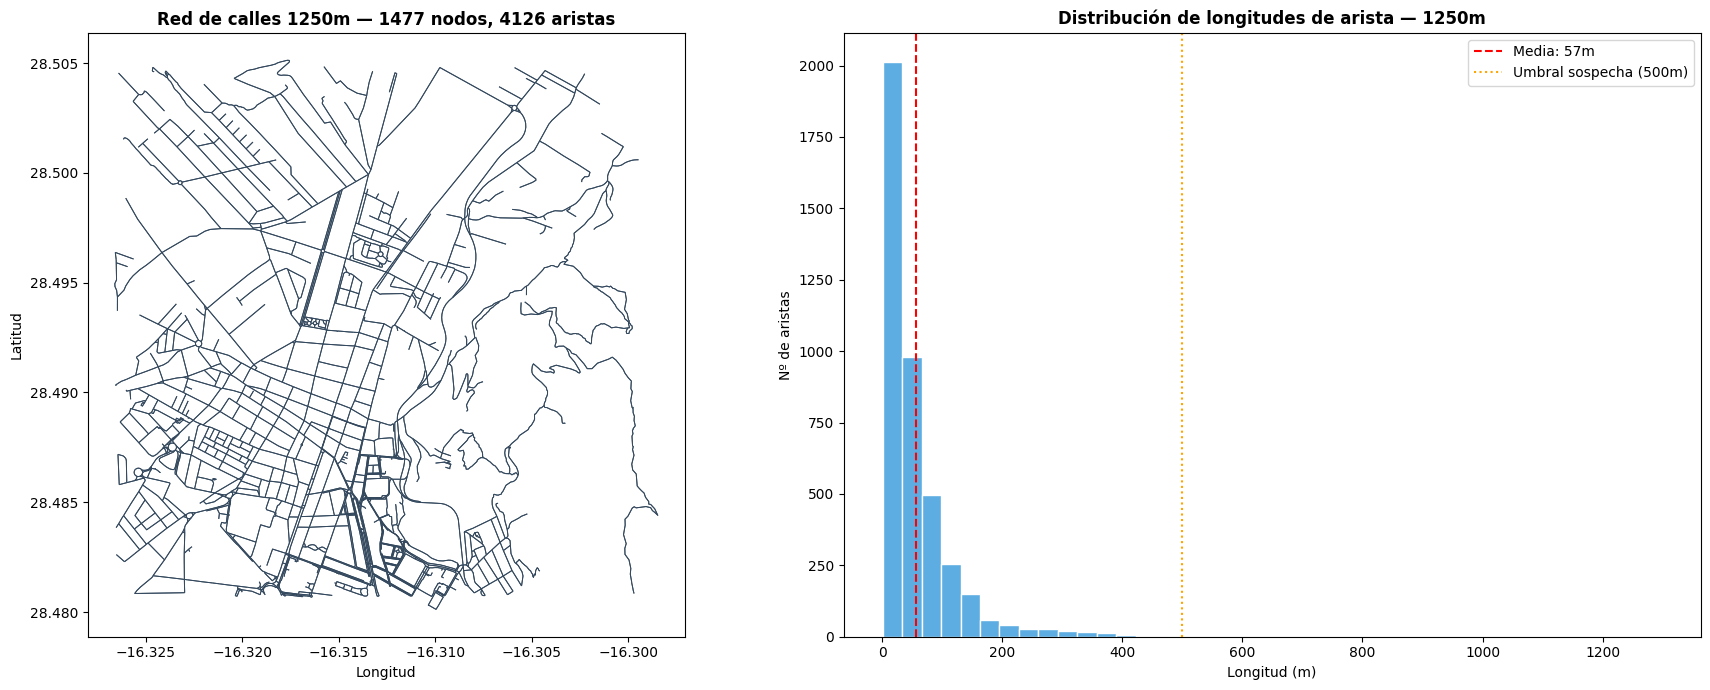


── Aristas > 500m (revisar) ──
Cantidad: 22
  646764496→2684216907: 1298m
  2684216907→646764496: 1298m
  552084199→2115559854: 845m
  2115559854→552084199: 845m
  11542591517→647043030: 758m

── Nodos aislados ──
Nodos aislados (componentes de tamaño 1): 0

════════════════════════════════════════════════════════════
═══ Sección A · Instancia 1500m ═══
════════════════════════════════════════════════════════════
CRS: epsg:4326
Nodos: 1969  Aristas: 5489

── Conectividad ──
Componentes conexas: 1
¿Grafo conexo?: ✓ SÍ

── Integridad de aristas ──
Aristas sin length o length≤0: 0
Longitud arista: min=0.7m  media=57.8m  max=1298.5m

── Candidatos artificiales en el grafo ──
Nodos artificiales (insertados sobre arista): 0


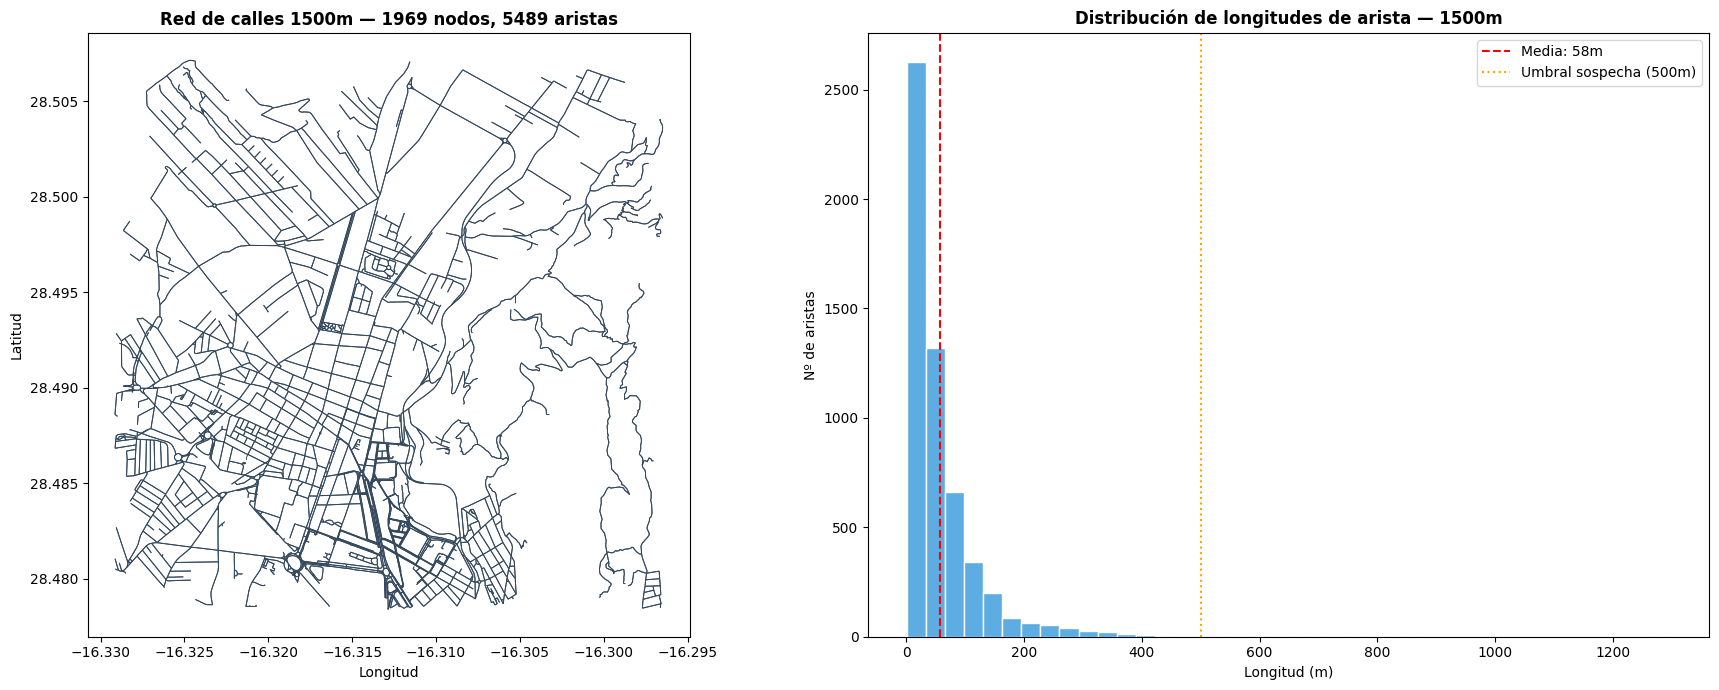


── Aristas > 500m (revisar) ──
Cantidad: 26
  646764496→2684216907: 1298m
  2684216907→646764496: 1298m
  552084199→2115559854: 845m
  2115559854→552084199: 845m
  722515197→722515228: 800m

── Nodos aislados ──
Nodos aislados (componentes de tamaño 1): 0


In [4]:
res_A = {}
for r in RADIOS:
    print("\n" + "═" * 60)
    print(f"═══ Sección A · Instancia {r}m ═══")
    print("═" * 60)
    res_A[r] = validar_grafo(r)

## Sección B — Edificios, demanda y detección de outliers

La **demanda** es el corazón del problema: cada edificio genera residuos según
su número estimado de habitantes `h_i`, y el modelo decide dónde poner
contenedores para cubrirla. Si la demanda está mal estimada, la solución
óptima lo estará también.

Actualmente `h_i` se estima como **área del edificio × plantas / superficie de
referencia** (30 m²/persona) y luego se **calibra** para que la suma total cuadre
con la densidad oficial del núcleo (INE ≈ 4471 hab/km²). Esto tiene limitaciones
que validamos aquí:

- **Outliers por arriba**: edificios enormes (un parking, un colegio, una nave)
  reciben un `h_i` gigante que no se corresponde con demanda doméstica real.
- **Outliers por abajo**: edificios diminutos (un trastero, un quiosco) con `h_i`
  mínimo.
- **Calibración**: comprobamos que el área del convex hull y la densidad
  resultante (suma `h_i` / área) ronden la densidad oficial usada para anclar.

Comprobamos la distribución de `h_i`, identificamos outliers, y comparamos la
población total estimada con un orden de magnitud razonable para la zona.

In [9]:
def validar_demanda(radius):
    """Sección B — Valida la demanda h_i de los edificios de una instancia.

    Para ``instancia_laguna_{radius}m.json``:
      - Estadística de ``h_i`` (min/media/mediana/max/desv) y población total.
      - Percentiles y detección de outliers por la regla del IQR (Q3 + 1.5·IQR).
      - Histograma de ``h_i`` + boxplot (puntos rojos = outliers).
      - Mapa de edificios coloreados por demanda, con los outliers marcados.
      - Fracción de la demanda total concentrada en los outliers.
      - Calibración: área del convex hull de los edificios (km²) y densidad
        resultante (suma h_i / área), que debe rondar la densidad oficial
        (INE ≈ 4471 hab/km²) usada para anclar la población.

    Si la instancia no existe, avisa y devuelve ``None``.
    Devuelve un dict con las métricas de demanda/calibración para la tabla.
    """
    inst_path = f"{DATA_DIR}/instancia_laguna_{radius}m.json"
    if not os.path.exists(inst_path):
        print(f"  ⚠️  No existe {inst_path} — se omite la validación de demanda {radius}m.")
        return None
    inst = load_instance(inst_path)

    # ── Extraer h_i de todos los edificios ────────────────────
    h_values = np.array([inst.I[i].h_i for i in inst.I])
    n_buildings = len(h_values)

    print(f"── Demanda por edificio (h_i) ──")
    print(f"Edificios: {n_buildings}")
    print(f"h_i:  min={h_values.min():.1f}  media={h_values.mean():.1f}  "
          f"mediana={np.median(h_values):.1f}  max={h_values.max():.1f}")
    print(f"Desv. típica: {h_values.std():.1f}")
    print(f"Población total estimada: {h_values.sum():.0f} habitantes")

    # ── Percentiles para detectar outliers ────────────────────
    p50, p90, p95, p99 = np.percentile(h_values, [50, 90, 95, 99])
    print(f"\n── Percentiles ──")
    print(f"p50 (mediana): {p50:.1f}")
    print(f"p90: {p90:.1f}   p95: {p95:.1f}   p99: {p99:.1f}")
    print(f"Edificios por encima de p99 ({p99:.0f}): {int(np.sum(h_values > p99))}")

    # ── Outliers: regla del rango intercuartílico (IQR) ───────
    # Un outlier estadístico está por encima de Q3 + 1.5·IQR
    q1, q3 = np.percentile(h_values, [25, 75])
    iqr = q3 - q1
    umbral_outlier = q3 + 1.5 * iqr
    outliers_idx = [i for i in inst.I if inst.I[i].h_i > umbral_outlier]
    print(f"\n── Outliers (regla IQR) ──")
    print(f"Umbral (Q3 + 1.5·IQR): {umbral_outlier:.1f}")
    print(f"Edificios outlier: {len(outliers_idx)}")
    print(f"Sus h_i: {sorted([round(inst.I[i].h_i) for i in outliers_idx], reverse=True)[:10]}")

    # ── Visualización: histograma + boxplot ───────────────────
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

    # Histograma de h_i
    ax1.hist(h_values, bins=50, color="#58d68d", edgecolor="white")
    ax1.axvline(np.median(h_values), color="blue", linestyle="--",
                label=f"Mediana: {np.median(h_values):.0f}")
    ax1.axvline(umbral_outlier, color="red", linestyle=":",
                label=f"Umbral outlier: {umbral_outlier:.0f}")
    ax1.set_title(f"Distribución de demanda h_i — {radius}m", fontsize=12, fontweight="bold")
    ax1.set_xlabel("Habitantes estimados por edificio")
    ax1.set_ylabel("Nº de edificios")
    ax1.legend(fontsize=10)

    # Boxplot (visualiza outliers claramente)
    ax2.boxplot(h_values, patch_artist=True,
                boxprops=dict(facecolor="#aed6f1"),
                flierprops=dict(marker="o", markerfacecolor="red",
                                markersize=5, alpha=0.5),
                labels=[f"{radius}m"])
    ax2.set_title(f"Boxplot de h_i — {radius}m (puntos rojos = outliers)",
                  fontsize=12, fontweight="bold")
    ax2.set_ylabel("Habitantes por edificio")

    plt.tight_layout()
    plt.show()

    # ── Mapa: edificios coloreados por demanda + outliers ─────
    fig, ax = plt.subplots(figsize=(14, 12))

    # Calles de fondo (si el grafo está disponible)
    graph_path = f"{DATA_DIR}/graph_{radius}m.graphml"
    if os.path.exists(graph_path):
        G = ox.load_graphml(graph_path)
        edges = ox.graph_to_gdfs(G, nodes=False)
        edges.plot(ax=ax, linewidth=0.5, edgecolor="#d5d8dc", zorder=1)
    else:
        print(f"  (grafo {radius}m no disponible: el mapa se dibuja sin calles de fondo)")

    # Edificios normales coloreados por demanda
    normal_idx = [i for i in inst.I if inst.I[i].h_i <= umbral_outlier]
    sc = ax.scatter([inst.I[i].longitude for i in normal_idx],
                    [inst.I[i].latitude for i in normal_idx],
                    c=[inst.I[i].h_i for i in normal_idx],
                    s=25, cmap="YlGnBu", alpha=0.8, zorder=3)
    plt.colorbar(sc, ax=ax, label="Habitantes (h_i)", shrink=0.5)

    # Outliers en rojo grande
    if outliers_idx:
        ax.scatter([inst.I[i].longitude for i in outliers_idx],
                   [inst.I[i].latitude for i in outliers_idx],
                   s=120, c="red", marker="X", edgecolors="darkred",
                   linewidth=1.5, zorder=6,
                   label=f"Outliers ({len(outliers_idx)})")
        # Etiquetar con su h_i
        for i in outliers_idx:
            ax.annotate(f"{inst.I[i].h_i:.0f}",
                        (inst.I[i].longitude, inst.I[i].latitude),
                        textcoords="offset points", xytext=(8, 8),
                        fontsize=8, fontweight="bold", color="darkred")
        ax.legend(fontsize=11)

    ax.set_title(f"Demanda por edificio {radius}m — outliers en rojo",
                 fontsize=14, fontweight="bold")
    ax.set_xlabel("Longitud"); ax.set_ylabel("Latitud")
    plt.tight_layout()
    plt.show()

    # ── ¿Qué fracción de la demanda total está en los outliers? ──
    demanda_total = h_values.sum()
    demanda_outliers = sum(inst.I[i].h_i for i in outliers_idx)
    print(f"Demanda total: {demanda_total:.0f}")
    if outliers_idx:
        print(f"Demanda en outliers: {demanda_outliers:.0f} "
              f"({100*demanda_outliers/demanda_total:.1f}% del total)")
    print(f"Outliers: {len(outliers_idx)} edificios "
          f"({100*len(outliers_idx)/n_buildings:.1f}%)")
    # Área de los outliers (estimada desde h_i, ref. 30 m²/hab) para ver si son
    # polígonos gigantes.
    areas_outliers = sorted([inst.I[i].h_i * 30 for i in outliers_idx], reverse=True)
    print(f"Áreas estimadas de los 10 mayores outliers (m²): "
          f"{[f'{a:.0f}' for a in areas_outliers[:10]]}")

    # ── Calibración: área del convex hull y densidad resultante ──
    # Reproduce el cálculo del generador: convex hull de los centroides de los
    # edificios en UTM → área en km²; densidad = suma h_i / área.
    pts = gpd.GeoSeries(gpd.points_from_xy(
        [inst.I[i].longitude for i in inst.I],
        [inst.I[i].latitude for i in inst.I]), crs="EPSG:4326")
    hull = pts.to_crs(pts.estimate_utm_crs()).unary_union.convex_hull
    area_km2 = hull.area / 1e6
    densidad = demanda_total / area_km2 if area_km2 > 0 else float("nan")
    print(f"\n── Calibración (densidad INE objetivo ≈ {DENSIDAD_INE:.0f} hab/km²) ──")
    print(f"Área convex hull: {area_km2:.4f} km²   "
          f"Densidad resultante: {densidad:.0f} hab/km²")

    return {
        "radius": radius,
        "n_edificios": n_buildings,
        "poblacion": float(demanda_total),
        "area_km2": float(area_km2),
        "densidad": float(densidad),
        "n_outliers": len(outliers_idx),
        "pct_demanda_outliers": 100 * demanda_outliers / demanda_total if demanda_total else 0.0,
    }


════════════════════════════════════════════════════════════
═══ Sección B · Instancia 1250m ═══
════════════════════════════════════════════════════════════
── Demanda por edificio (h_i) ──
Edificios: 2258
h_i:  min=1.0  media=12.4  mediana=4.4  max=519.1
Desv. típica: 30.0
Población total estimada: 28092 habitantes

── Percentiles ──
p50 (mediana): 4.4
p90: 26.0   p95: 51.3   p99: 140.8
Edificios por encima de p99 (141): 23

── Outliers (regla IQR) ──
Umbral (Q3 + 1.5·IQR): 18.0
Edificios outlier: 315
Sus h_i: [519, 356, 350, 316, 313, 309, 272, 265, 241, 237]


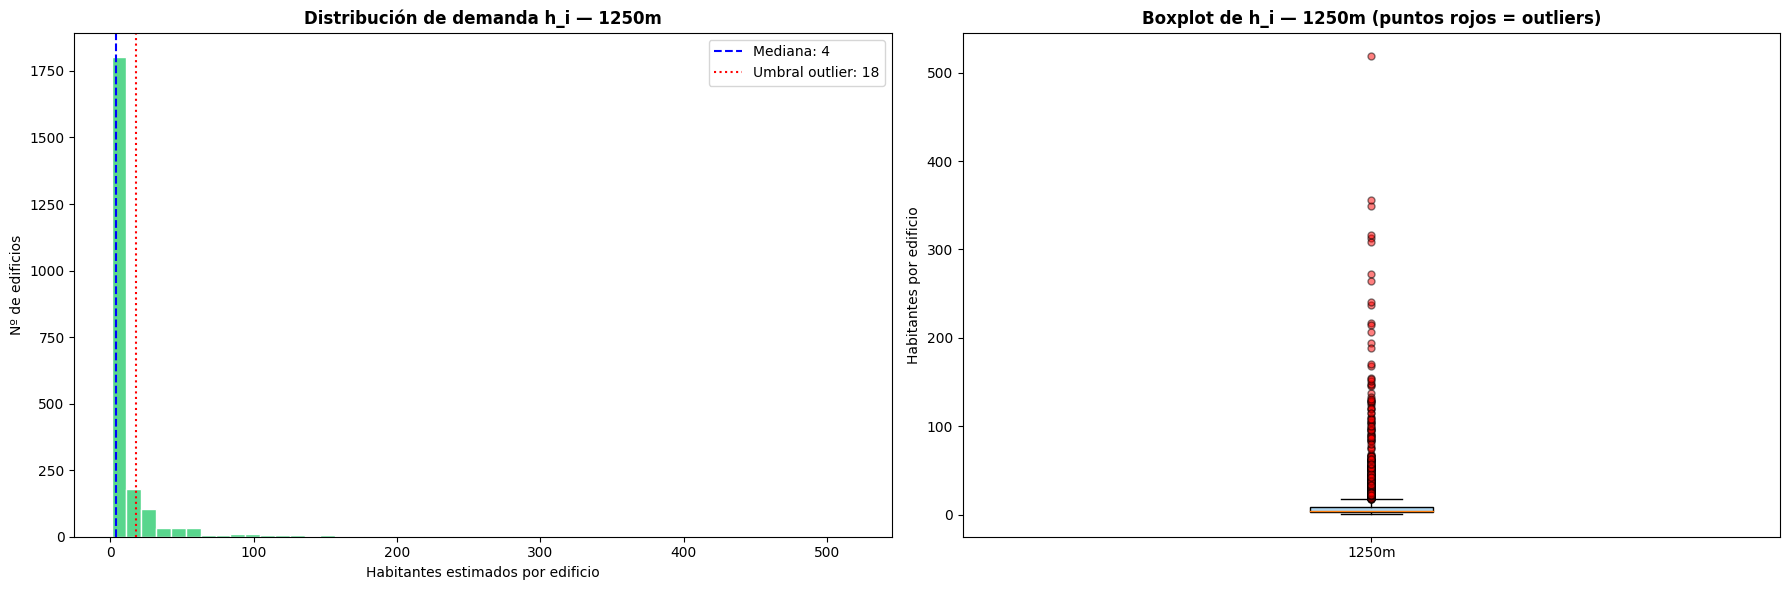

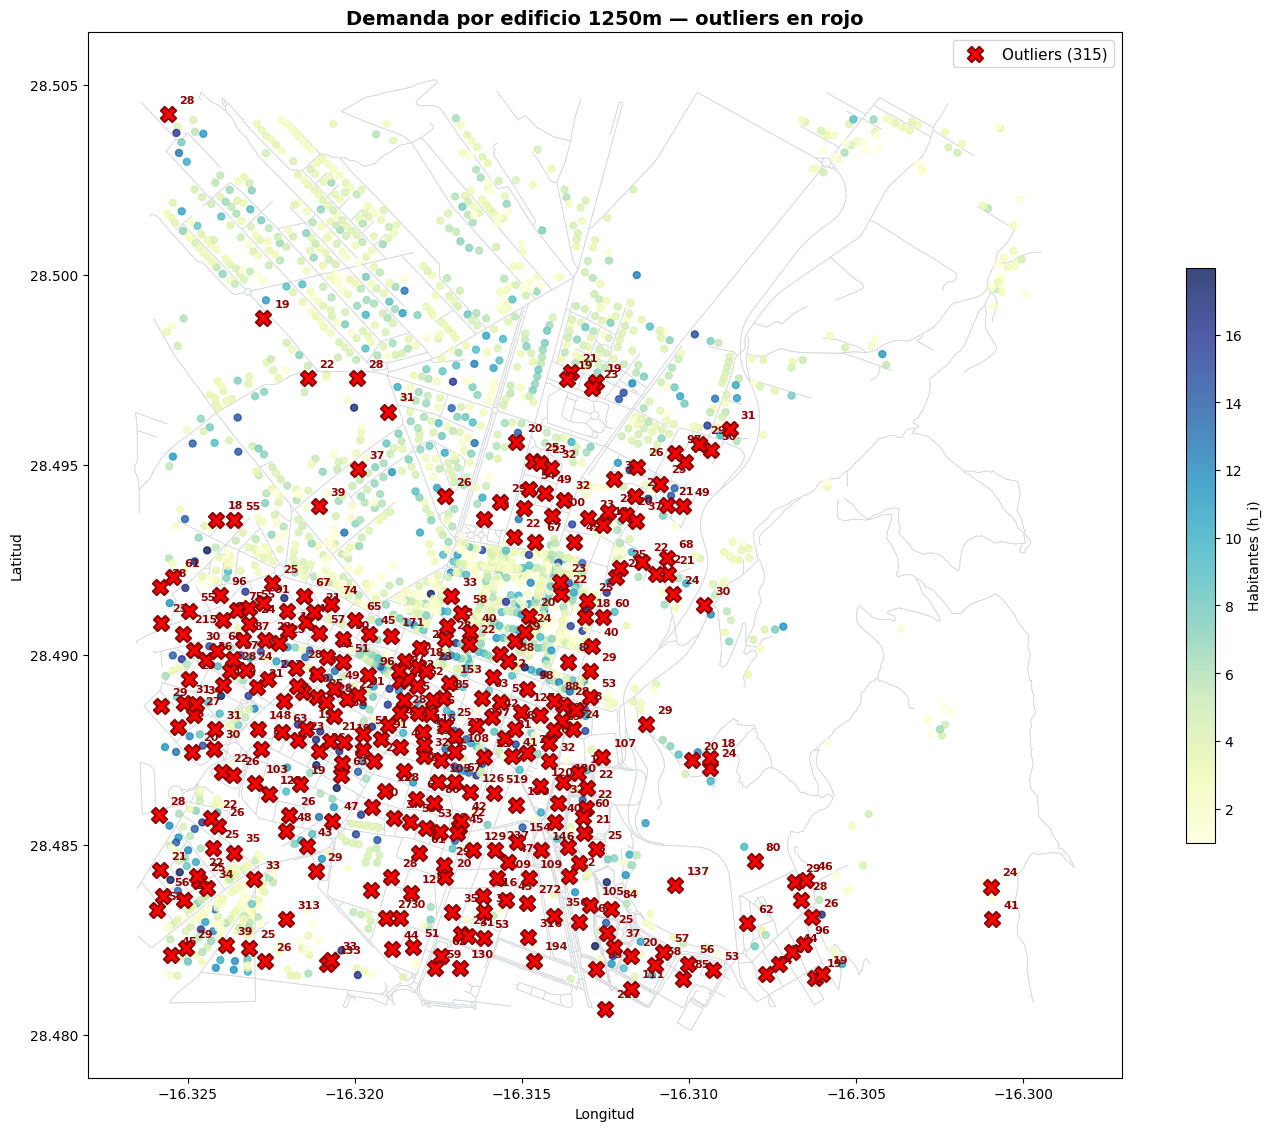

Demanda total: 28092
Demanda en outliers: 18689 (66.5% del total)
Outliers: 315 edificios (14.0%)
Áreas estimadas de los 10 mayores outliers (m²): ['15574', '10669', '10486', '9489', '9390', '9255', '8160', '7942', '7221', '7111']

── Calibración (densidad INE objetivo ≈ 4471 hab/km²) ──
Área convex hull: 6.2646 km²   Densidad resultante: 4484 hab/km²

════════════════════════════════════════════════════════════
═══ Sección B · Instancia 1500m ═══
════════════════════════════════════════════════════════════
── Demanda por edificio (h_i) ──
Edificios: 2958
h_i:  min=1.0  media=13.5  mediana=4.8  max=579.5
Desv. típica: 31.2
Población total estimada: 39802 habitantes

── Percentiles ──
p50 (mediana): 4.8
p90: 30.2   p95: 57.5   p99: 143.3
Edificios por encima de p99 (143): 30

── Outliers (regla IQR) ──
Umbral (Q3 + 1.5·IQR): 20.2
Edificios outlier: 418
Sus h_i: [580, 397, 390, 353, 349, 344, 304, 296, 269, 265]


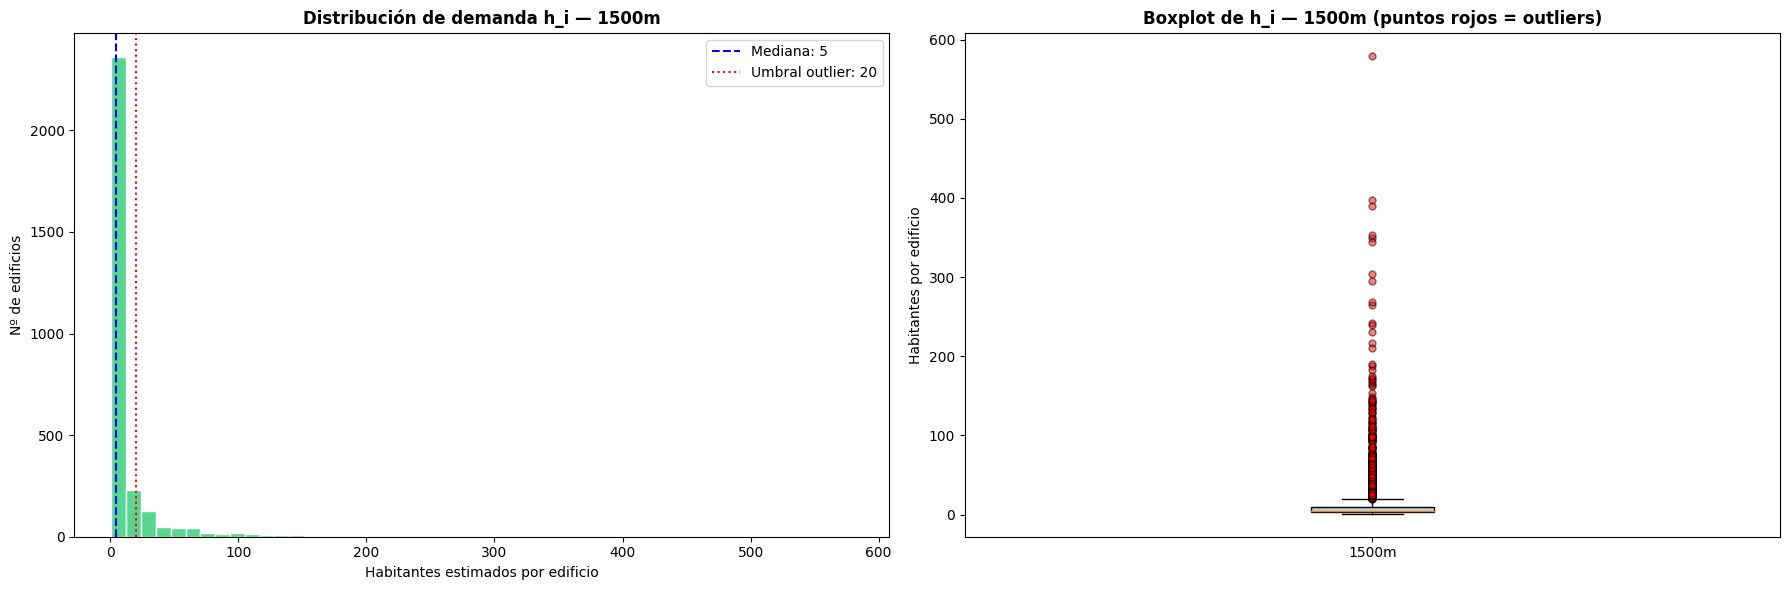

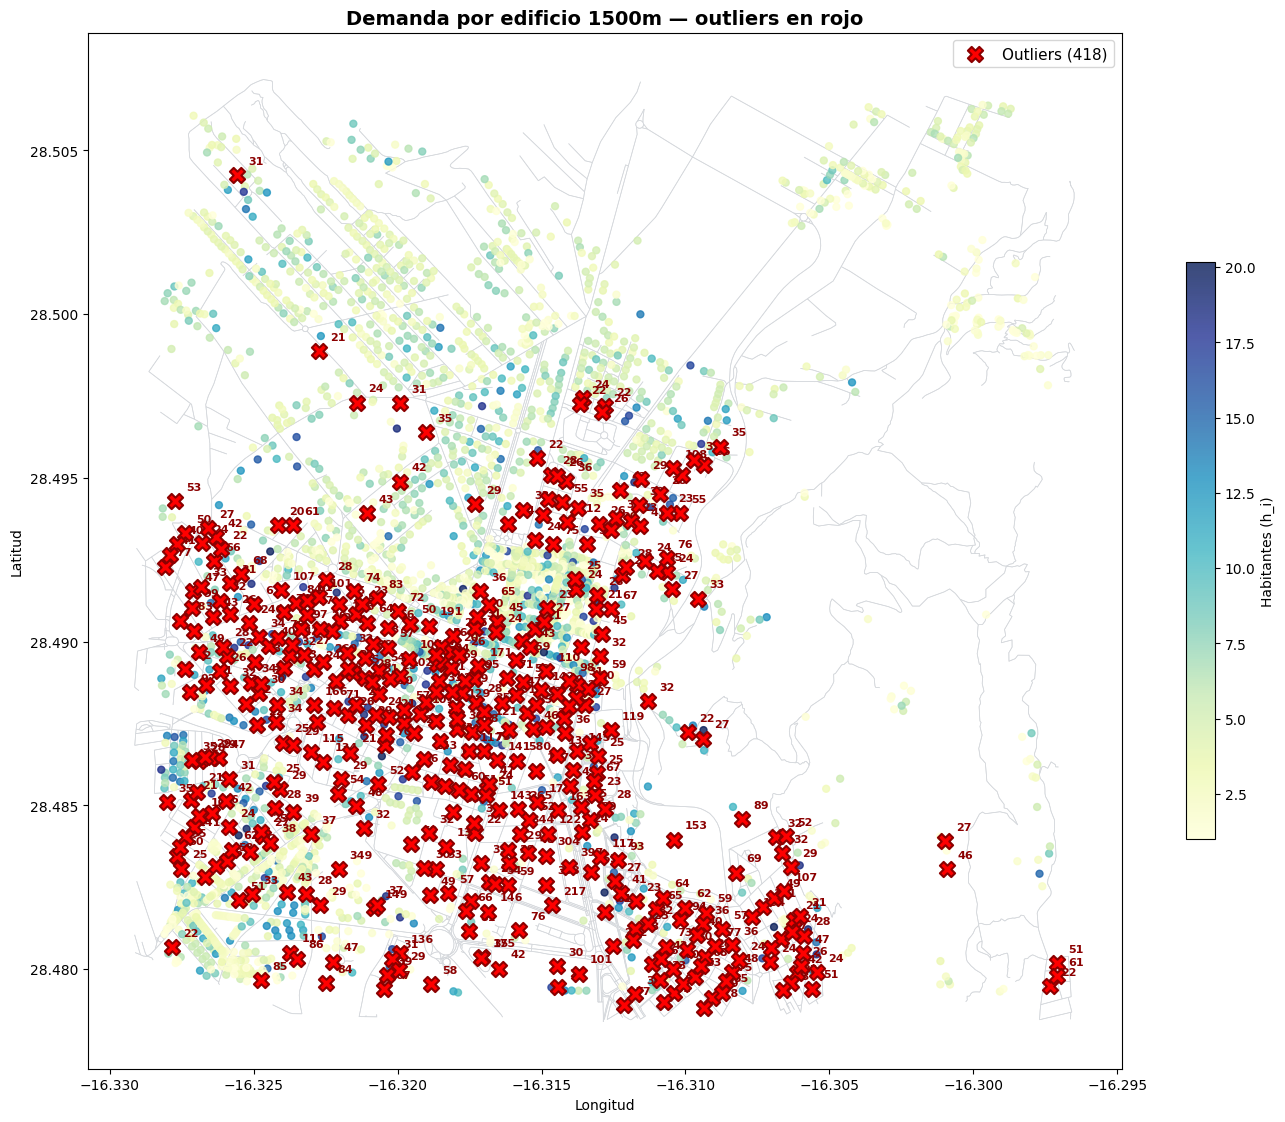

Demanda total: 39802
Demanda en outliers: 26519 (66.6% del total)
Outliers: 418 edificios (14.1%)
Áreas estimadas de los 10 mayores outliers (m²): ['17386', '11910', '11705', '10593', '10483', '10332', '9109', '8865', '8061', '7937']

── Calibración (densidad INE objetivo ≈ 4471 hab/km²) ──
Área convex hull: 8.9518 km²   Densidad resultante: 4446 hab/km²


In [10]:
res_B = {}
for r in RADIOS:
    print("\n" + "═" * 60)
    print(f"═══ Sección B · Instancia {r}m ═══")
    print("═" * 60)
    res_B[r] = validar_demanda(r)

## Sección C — Distancias y cobertura

Las **distancias** edificio→candidato son la base de las restricciones de cobertura:
un candidato "cubre" un edificio para un tipo de residuo `k` si la distancia entre
ellos es ≤ `coverage_radius[k]`. Validamos que:

- **Las distancias son realistas**: sin ceros (bug antiguo de proyección al nodo),
  acotadas por el `cutoff_dijkstra`, con una distribución coherente.
- **La interpolación funciona**: la distancia mínima refleja el tramo perpendicular
  edificio→calle (`d_perp`), no un 0 artificial.
- **Cada edificio tiene cobertura completa**: al menos un candidato dentro del radio
  para CADA tipo de residuo. Si la generación es correcta, debe ser el 100%.
- **La cobertura por tipo es coherente**: los tipos con radio menor (orgánico/resto,
  100m) tienen menos candidatos accesibles que los de radio mayor (peligroso, 300m).

Si esta sección pasa, la instancia está lista para resolverse.

In [11]:
def validar_distancias_cobertura(radius):
    """Sección C — Valida distancias edificio→candidato y cobertura.

    Para ``instancia_laguna_{radius}m.json``:
      - Estadística de las distancias (min/media/mediana/max) y nº de conexiones.
      - Chequeos de sanidad: sin distancias 0.0 m (bug antiguo de proyección),
        conteo de conexiones <5 m, y que ninguna exceda el cutoff (max radio).
      - Histograma de distancias con los radios de cobertura marcados.
      - Cobertura por edificio y tipo: nº de edificios sin cobertura (debe ser 0)
        y desglose por tipo de residuo.
      - Candidatos accesibles por edificio (media/min/max) por tipo, y boxplot.
      - Desglose de candidatos reales vs artificiales (id negativo).

    Si la instancia no existe, avisa y devuelve ``None``.
    Devuelve un dict con las métricas de distancia/cobertura para la tabla.
    """
    inst_path = f"{DATA_DIR}/instancia_laguna_{radius}m.json"
    if not os.path.exists(inst_path):
        print(f"  ⚠️  No existe {inst_path} — se omite la validación de distancias/cobertura {radius}m.")
        return None
    inst = load_instance(inst_path)
    params = inst.params

    # ── Recopilar todas las distancias ────────────────────────
    all_dists = np.array([d for j in inst.dij.values() for d in j.values()])

    print(f"── Distancias edificio→candidato ──")
    print(f"Total conexiones: {len(all_dists)}")
    print(f"min={all_dists.min():.1f}m  media={all_dists.mean():.1f}m  "
          f"mediana={np.median(all_dists):.1f}m  max={all_dists.max():.1f}m")

    # ── Chequeos de sanidad ───────────────────────────────────
    print(f"\n── Chequeos de sanidad ──")
    print(f"Conexiones a 0.0m (bug antiguo): {int(np.sum(all_dists == 0))}  "
          f"{'✓ OK' if np.sum(all_dists == 0) == 0 else '✗ HAY CEROS'}")
    print(f"Conexiones < 5m: {int(np.sum(all_dists < 5))}")
    cutoff = max(params.coverage_radius.values())
    print(f"Cutoff (max coverage_radius): {cutoff}m")
    print(f"Conexiones > cutoff: {int(np.sum(all_dists > cutoff))}  "
          f"{'✓ OK' if np.sum(all_dists > cutoff) == 0 else '✗ EXCEDEN'}")

    # ── Visualización: histograma + radios marcados ───────────
    fig, ax = plt.subplots(figsize=(14, 6))
    ax.hist(all_dists, bins=50, color="#5dade2", edgecolor="white", alpha=0.8)

    # Marcar cada radio de cobertura
    colores = ["#27ae60", "#27ae60", "#e67e22", "#c0392b"]
    nombres = ["Orgánico/Resto", "", "Reciclable", "Peligroso"]
    radios_vistos = set()
    for k, r in params.coverage_radius.items():
        if r not in radios_vistos:
            ax.axvline(r, color=colores[k], linestyle="--", linewidth=1.5,
                       label=f"{nombres[k] or 'tipo '+str(k)}: {r:.0f}m")
            radios_vistos.add(r)

    ax.set_title(f"Distribución de distancias — {radius}m", fontsize=13, fontweight="bold")
    ax.set_xlabel("Distancia edificio→candidato (m)")
    ax.set_ylabel("Nº de conexiones")
    ax.legend(fontsize=10)
    plt.tight_layout()
    plt.show()

    # ── Validar cobertura: cada edificio, cada tipo ───────────
    n_i = len(inst.I)
    n_k = len(inst.K)

    # Para cada edificio, ¿cuántos candidatos lo cubren por tipo?
    cobertura = np.zeros((n_i, n_k), dtype=int)
    for j in inst.dij:
        for i, d in inst.dij[j].items():
            for k in range(n_k):
                if d <= params.coverage_radius[k]:
                    cobertura[i, k] += 1

    # ── Edificios sin cobertura en algún tipo ─────────────────
    sin_cobertura_por_tipo = {k: int(np.sum(cobertura[:, k] == 0)) for k in range(n_k)}
    edificios_descubiertos = int(np.sum(np.any(cobertura == 0, axis=1)))

    print(f"\n── Cobertura ──")
    print(f"Edificios: {n_i}")
    print(f"Edificios SIN cobertura completa: {edificios_descubiertos}  "
          f"{'✓ COBERTURA TOTAL' if edificios_descubiertos == 0 else '✗ HAY HUECOS'}")
    print(f"\nEdificios sin cobertura por tipo:")
    for k in range(n_k):
        print(f"  {TIPO_NOMBRES.get(k, f'tipo {k}')} (r={params.coverage_radius[k]:.0f}m): "
              f"{sin_cobertura_por_tipo[k]} sin cubrir")

    # ── Candidatos accesibles por edificio (media por tipo) ───
    print(f"\n── Candidatos accesibles por edificio (media) ──")
    acc_por_tipo = {}
    for k in range(n_k):
        media = cobertura[:, k].mean()
        acc_por_tipo[k] = float(media)
        print(f"  {TIPO_NOMBRES.get(k, f'tipo {k}')} (r={params.coverage_radius[k]:.0f}m): "
              f"media={media:.1f}  min={cobertura[:, k].min()}  max={cobertura[:, k].max()}")

    # ── Visualización: candidatos accesibles por tipo ─────────
    fig, ax = plt.subplots(figsize=(12, 6))
    bp = ax.boxplot([cobertura[:, k] for k in range(n_k)],
                    labels=[f"{TIPO_NOMBRES.get(k, k)}\n{params.coverage_radius[k]:.0f}m"
                                 for k in range(n_k)],
                    patch_artist=True)
    for patch, color in zip(bp["boxes"], ["#a9dfbf", "#a9dfbf", "#f5cba7", "#f1948a"]):
        patch.set_facecolor(color)
    ax.set_title(f"Candidatos accesibles por edificio, según tipo — {radius}m",
                 fontsize=13, fontweight="bold")
    ax.set_ylabel("Nº de candidatos dentro del radio")
    ax.grid(True, alpha=0.2, axis="y")
    plt.tight_layout()
    plt.show()

    # ── Candidatos: reales vs artificiales (id negativo) ──────
    n_cand = len(inst.J)
    n_artif = sum(1 for j in inst.J if str(inst.J[j].osm_id).startswith("-"))
    n_reales = n_cand - n_artif
    print(f"\n── Candidatos ──")
    print(f"Total: {n_cand}  (reales: {n_reales}, artificiales: {n_artif})")

    return {
        "radius": radius,
        "n_candidatos": n_cand,
        "n_cand_reales": n_reales,
        "n_cand_artificiales": n_artif,
        "n_conexiones": len(all_dists),
        "dist_media": float(all_dists.mean()),
        "dist_max": float(all_dists.max()),
        "edificios_sin_cobertura": edificios_descubiertos,
        "acc_por_tipo": acc_por_tipo,
    }


════════════════════════════════════════════════════════════
═══ Sección C · Instancia 1250m ═══
════════════════════════════════════════════════════════════
── Distancias edificio→candidato ──
Total conexiones: 26406
min=4.9m  media=148.5m  mediana=158.3m  max=225.0m

── Chequeos de sanidad ──
Conexiones a 0.0m (bug antiguo): 0  ✓ OK
Conexiones < 5m: 1
Cutoff (max coverage_radius): 225.0m
Conexiones > cutoff: 0  ✓ OK


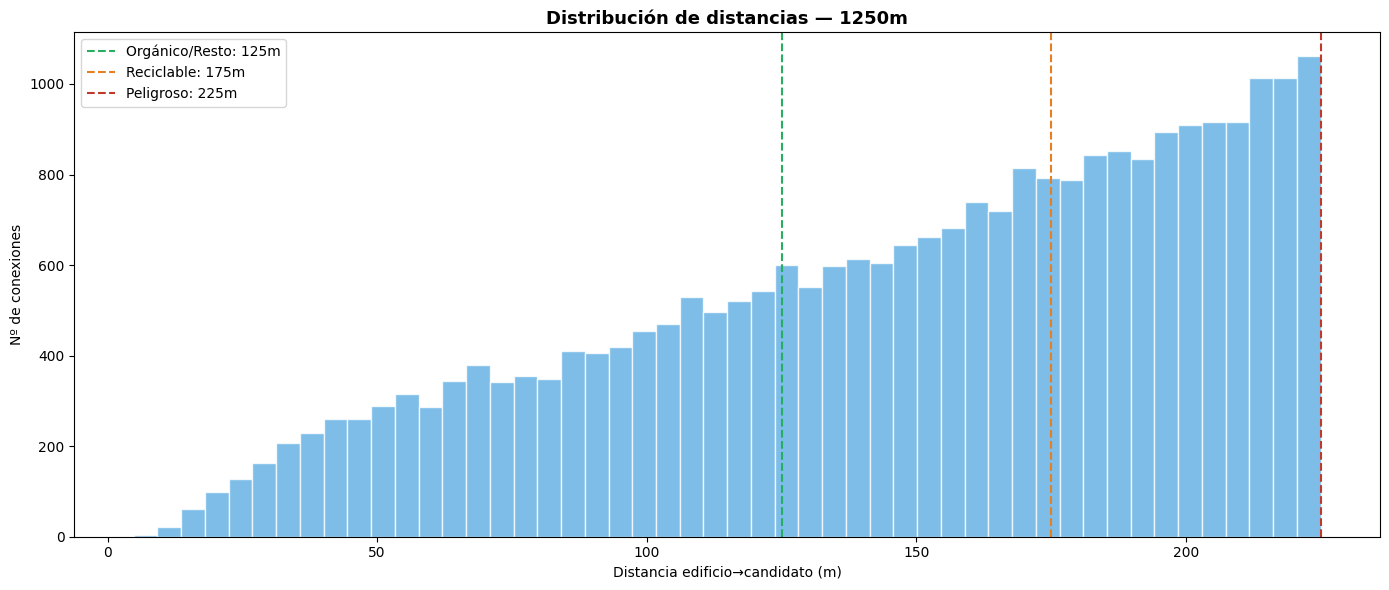


── Cobertura ──
Edificios: 2258
Edificios SIN cobertura completa: 0  ✓ COBERTURA TOTAL

Edificios sin cobertura por tipo:
  Orgánico (r=125m): 0 sin cubrir
  Resto (r=125m): 0 sin cubrir
  Papel/Carton (r=175m): 0 sin cubrir
  Vidrio (r=225m): 0 sin cubrir

── Candidatos accesibles por edificio (media) ──
  Orgánico (r=125m): media=3.8  min=1  max=18
  Resto (r=125m): media=3.8  min=1  max=18
  Papel/Carton (r=175m): media=7.1  min=1  max=30
  Vidrio (r=225m): media=11.7  min=1  max=41


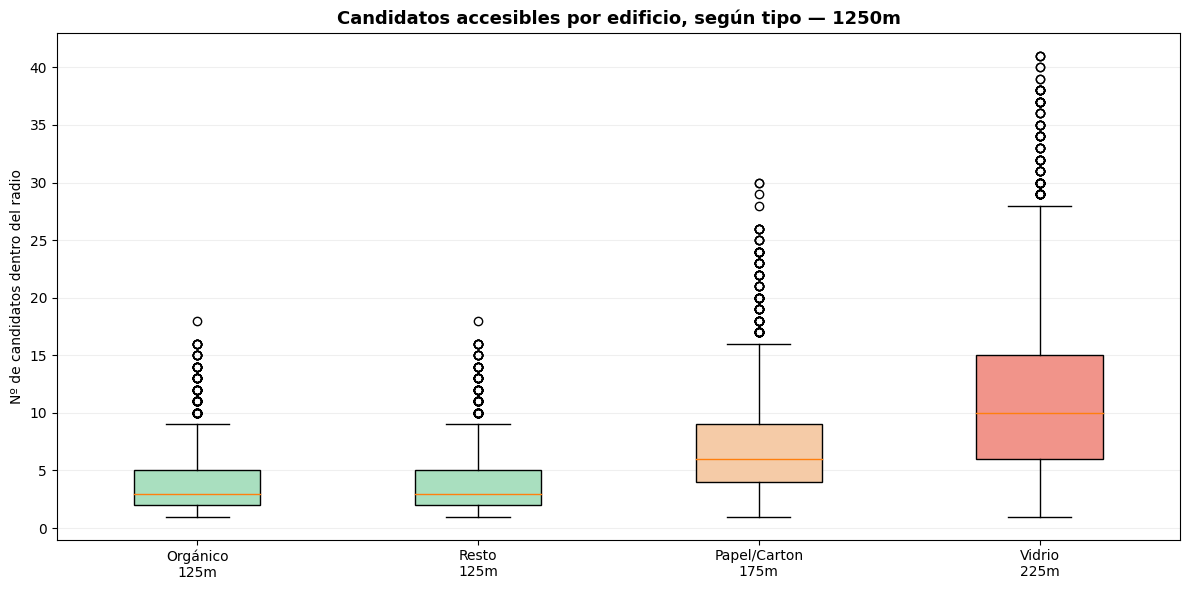


── Candidatos ──
Total: 928  (reales: 845, artificiales: 83)

════════════════════════════════════════════════════════════
═══ Sección C · Instancia 1500m ═══
════════════════════════════════════════════════════════════
── Distancias edificio→candidato ──
Total conexiones: 34846
min=4.9m  media=148.5m  mediana=158.2m  max=225.0m

── Chequeos de sanidad ──
Conexiones a 0.0m (bug antiguo): 0  ✓ OK
Conexiones < 5m: 2
Cutoff (max coverage_radius): 225.0m
Conexiones > cutoff: 0  ✓ OK


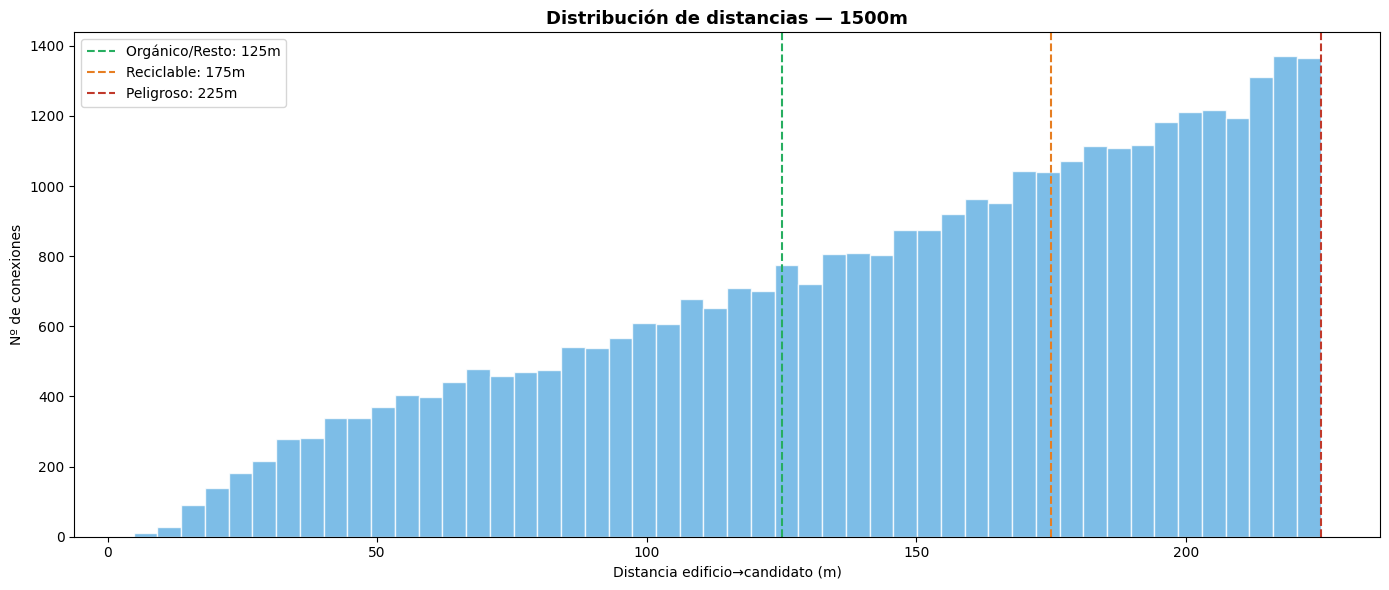


── Cobertura ──
Edificios: 2958
Edificios SIN cobertura completa: 0  ✓ COBERTURA TOTAL

Edificios sin cobertura por tipo:
  Orgánico (r=125m): 0 sin cubrir
  Resto (r=125m): 0 sin cubrir
  Papel/Carton (r=175m): 0 sin cubrir
  Vidrio (r=225m): 0 sin cubrir

── Candidatos accesibles por edificio (media) ──
  Orgánico (r=125m): media=3.8  min=1  max=19
  Resto (r=125m): media=3.8  min=1  max=19
  Papel/Carton (r=175m): media=7.2  min=1  max=30
  Vidrio (r=225m): media=11.8  min=1  max=41


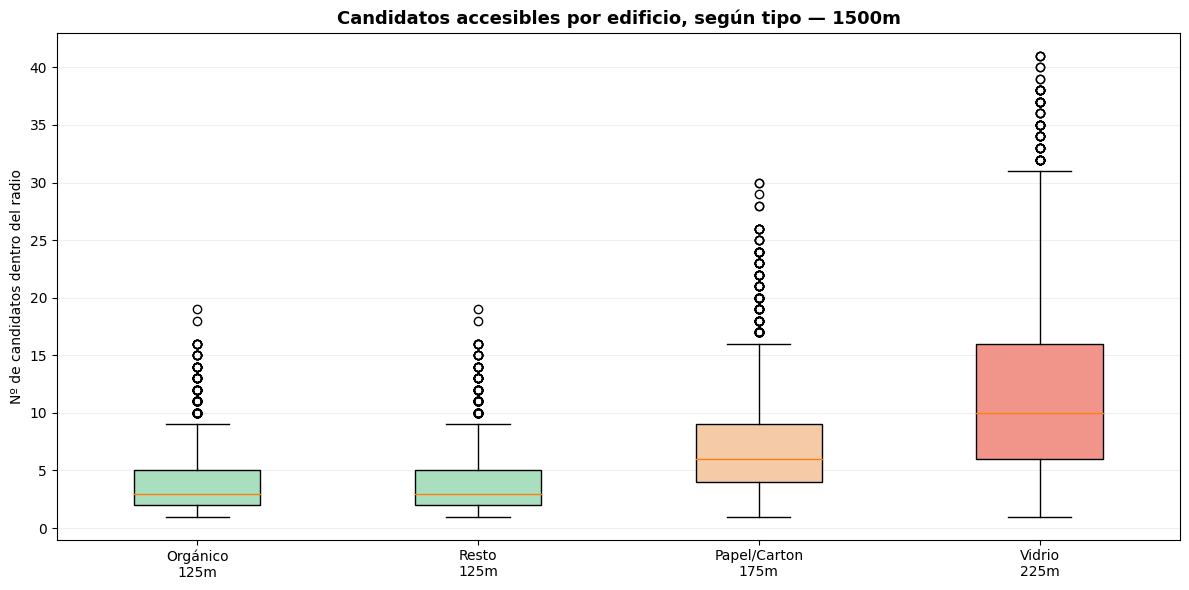


── Candidatos ──
Total: 1265  (reales: 1147, artificiales: 118)


In [12]:
res_C = {}
for r in RADIOS:
    print("\n" + "═" * 60)
    print(f"═══ Sección C · Instancia {r}m ═══")
    print("═" * 60)
    res_C[r] = validar_distancias_cobertura(r)

## Tabla comparativa de instancias

Reúne las métricas clave de cada radio en una sola tabla para compararlas de un
vistazo. Sirve para verificar la **coherencia** entre instancias:

- la **densidad** calibrada debe rondar **4471 hab/km²** en todas (la calibración
  ancla la población a ese dato del INE; pequeñas desviaciones al alza vienen del
  recorte `h_i ≥ 1`);
- los **edificios sin cobertura** deben ser **0** en todas;
- **edificios**, **candidatos** y **conexiones** deben **crecer con el radio**.

Las columnas `Acc. *` son la media de candidatos accesibles por edificio para cada
tipo de residuo (deben crecer con el radio de cobertura del tipo). Solo se incluyen
las instancias presentes en disco; las ausentes se avisan y se omiten.

In [30]:
filas = []
for r in RADIOS:
    b = res_B.get(r)
    c = res_C.get(r)
    if b is None or c is None:
        print(f"⚠️  Instancia {r}m incompleta o ausente — excluida de la tabla comparativa.")
        continue
    acc = c["acc_por_tipo"]
    filas.append({
        "Radio (m)": r,
        "Edificios": b["n_edificios"],
        "Candidatos (tot · real/artif)": f'{c["n_candidatos"]} ({c["n_cand_reales"]}/{c["n_cand_artificiales"]})',
        "Población (Σh_i)": round(b["poblacion"]),
        "Área (km²)": round(b["area_km2"], 4),
        "Densidad (hab/km²)": round(b["densidad"]),
        "Conexiones": c["n_conexiones"],
        "Dist. media (m)": round(c["dist_media"], 1),
        "Dist. máx (m)": round(c["dist_max"], 1),
        "Sin cobertura": c["edificios_sin_cobertura"],
        "Acc. Orgánico": round(acc.get(0, float("nan")), 1),
        "Acc. Resto": round(acc.get(1, float("nan")), 1),
        "Acc. Reciclable": round(acc.get(2, float("nan")), 1),
        "Acc. Peligroso": round(acc.get(3, float("nan")), 1),
    })

if not filas:
    print("No hay instancias completas para comparar. Genera al menos una instancia "
          "(data/processed/instancia_laguna_{R}m.json) y reejecuta los bucles.")
else:
    pd.set_option("display.max_columns", None)
    pd.set_option("display.width", 220)
    df = pd.DataFrame(filas).set_index("Radio (m)")
    print("═" * 70)
    print("TABLA COMPARATIVA DE INSTANCIAS")
    print("Comprobaciones: densidad ≈ 4471 hab/km² y 'Sin cobertura' = 0 en todas;")
    print("edificios / candidatos / conexiones crecientes con el radio.")
    print("═" * 70)
    display(df)

══════════════════════════════════════════════════════════════════════
TABLA COMPARATIVA DE INSTANCIAS
Comprobaciones: densidad ≈ 4471 hab/km² y 'Sin cobertura' = 0 en todas;
edificios / candidatos / conexiones crecientes con el radio.
══════════════════════════════════════════════════════════════════════


,Edificios,Candidatos (tot · real/artif),Población (Σh_i),Área (km²),Densidad (hab/km²),Conexiones,Dist. media (m),Dist. máx (m),Sin cobertura,Acc. Orgánico,Acc. Resto,Acc. Reciclable,Acc. Peligroso
Radio (m),,,,,,,,,,,,,
250,243,80 (75/5),1149,0.2512,4575,5371,201.2,300.0,0,2.5,2.5,5.3,18.5
300,346,103 (92/11),1650,0.3615,4564,7136,197.7,300.0,0,2.5,2.5,5.3,17.4
350,446,116 (100/16),2184,0.4804,4545,8869,198.3,300.0,0,2.4,2.4,5.0,16.8
400,546,146 (125/21),2944,0.6501,4529,11236,198.6,300.0,0,2.4,2.4,5.2,17.4
